In [1]:
# --------------------------
# 新增模型：基于 Random Forest 的检测方法
# 注意：该模型使用 scikit-learn 的 RandomForestClassifier，不继承 nn.Module，因此不能直接用于 GPU 加速训练
# 使用时请确保输入为 numpy 数组，形状为 (n_samples, channel, feature_len)，并可无缝替换之前模型接口
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt
from datasets import *
from sklearn.metrics import recall_score, f1_score, roc_auc_score, accuracy_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
import shap
import reload_shap_plot

In [2]:
class RFClassifier:
    def __init__(self, feature_len, channel=1, n_estimators=100, random_state=42):
        """
        feature_len: 每个通道的特征数量
        channel: 输入通道数
        n_estimators: 随机森林中的树数量
        random_state: 随机种子
        """
        self.num_features = channel * feature_len
        self.rf = RandomForestClassifier(n_estimators=n_estimators, random_state=random_state)
    
    def fit(self, x, y):
        """
        x: numpy 数组，形状为 (n_samples, channel, feature_len)
        y: 标签数组，形状为 (n_samples,)
        """
        n_samples = x.shape[0]
        # 将每个样本的 (channel, feature_len) 展平为一个向量
        x_flat = x.reshape(n_samples, -1)
        self.rf.fit(x_flat, y)
    
    def predict(self, x):
        """
        x: numpy 数组，形状为 (n_samples, channel, feature_len)
        返回: 预测标签数组
        """
        n_samples = x.shape[0]
        x_flat = x.reshape(n_samples, -1)
        return self.rf.predict(x_flat)
    
    def predict_proba(self, x):
        """
        x: numpy 数组，形状为 (n_samples, channel, feature_len)
        返回: 预测概率数组
        """
        n_samples = x.shape[0]
        x_flat = x.reshape(n_samples, -1)
        return self.rf.predict_proba(x_flat)

In [3]:
dataset = BinaryDataset('Node123_loop')
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size], generator=torch.Generator().manual_seed(20))
feature_names = [f'Bus {i+1}' for i in range(1, dataset.n_buses + 1)]

In [4]:
model = RFClassifier(feature_len=dataset.n_buses, channel=1)

In [5]:
model.fit(train_dataset.dataset.data, train_dataset.dataset.labels)

/home/xiangyu/.local/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [6]:
# Get predictions
y_true = test_dataset.dataset.labels[test_dataset.indices]
y_pred = model.predict(test_dataset.dataset.data[test_dataset.indices])
y_proba = model.predict_proba(test_dataset.dataset.data[test_dataset.indices])[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_proba)

# Print metrics
print(f'Accuracy: {accuracy}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print(f'AUC: {auc}')

Accuracy: 1.0
Recall: 1.0
F1 Score: 1.0
AUC: 1.0


# Explain

In [7]:
label_1_samples = []
label_0_samples = []
for data, label in train_dataset:
    if label.item() == 1:  # Filter label 1 samples
        label_1_samples.append(data)  # Convert to NumPy for SHAP
    else: 
        label_0_samples.append(data)

# Convert to NumPy array for SHAP compatibility
label_0_samples = np.array(label_0_samples)
label_1_samples = np.array(label_1_samples)

print(label_0_samples.shape)
print(label_1_samples.shape)

(800, 1, 122)
(800, 1, 122)


In [8]:
# Compute mean background from normal (label 0) samples
background_mean = label_0_samples.mean(0)  # Compute mean across samples
# background_mean = torch.tensor(np.zeros_like(background_mean)+0.1, dtype=torch.float32)  # Use zero mean as background

# Ensure at least (n_buses + 1) samples
n_buses = background_mean.shape[-1]
num_background_samples = n_buses + 1  # Ensure SHAP has enough samples

# Convert to NumPy for SHAP
background = background_mean

""" Check this line of code """
background = np.tile(background, (2, 1))  # Expand background size *2

background.shape

(2, 122)

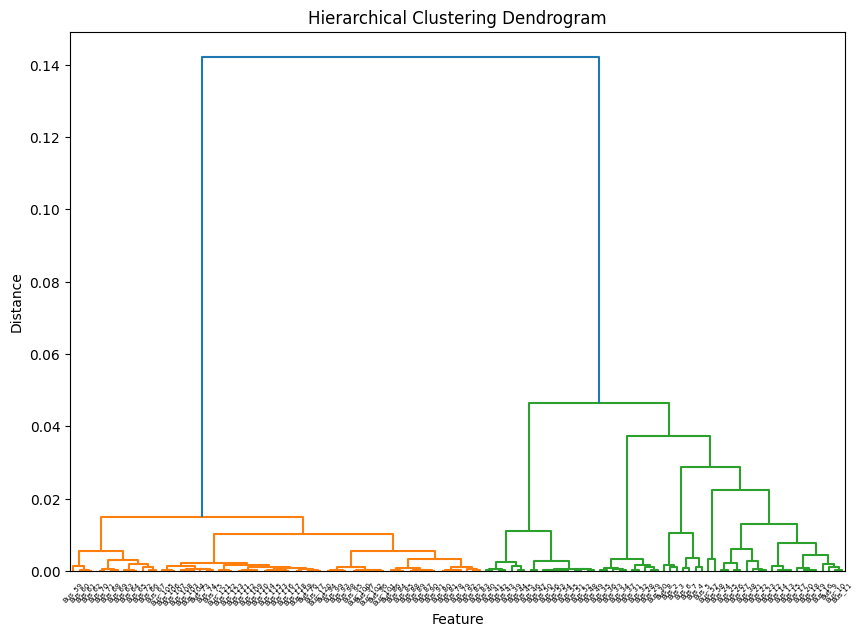

In [9]:
def get_matrix_from_data(data_normal, data_outage):
    # # Combine the two datasets
    # combined_data = pd.concat([data_normal, data_outage])
    combined_data = data_normal
    # combined_data = data_outage

    # Compute the correlation matrix
    corr_matrix = combined_data.corr()

    # Convert the correlation matrix to a distance matrix
    distance_matrix = 1 - corr_matrix

    # Perform hierarchical clustering
    Z = linkage(squareform(distance_matrix), method='average')
    return Z, corr_matrix

Z, corr_matrix = get_matrix_from_data(dataset.data_df, dataset.data_outage_df)

# Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(Z, labels=corr_matrix.columns, leaf_rotation=45)
# dendrogram(Z, leaf_rotation=45)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Feature')
plt.ylabel('Distance')
plt.show()

In [10]:
instance = label_1_samples[0]
instance.shape

(1, 122)

In [11]:
def model_wrapper(x):
    # Get prediction
    return model.predict_proba(x)[:, 1]

In [12]:
# Initialize SHAP Explainer
masker = shap.maskers.Partition(background)
masker.clustering = Z  # 强制使用你的 partition_tree
explainer = shap.PartitionExplainer(model_wrapper, masker, feature_names=feature_names)

In [13]:
shap_values = explainer(label_1_samples.squeeze())

PartitionExplainer explainer: 801it [01:04, 10.50it/s]                         


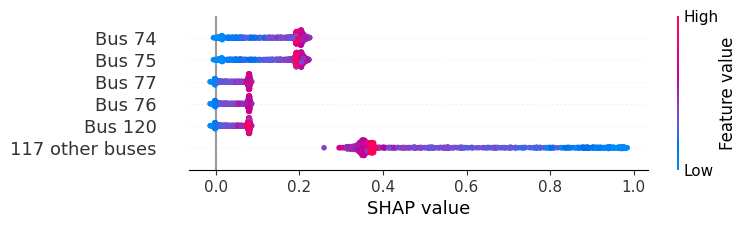

In [14]:
shap.plots.beeswarm(shap_values, max_display=6, plot_size=(7.4, 2))

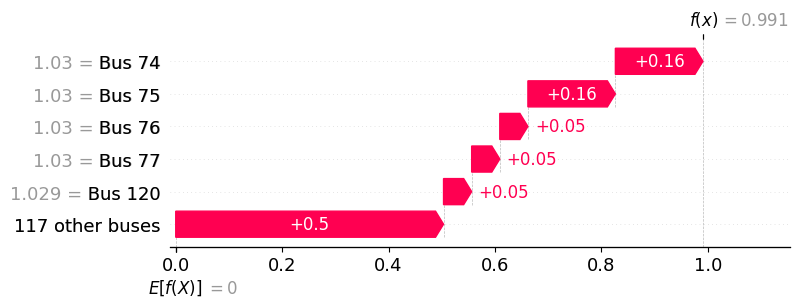

In [15]:
shap.plots.waterfall(shap_values.mean(0))

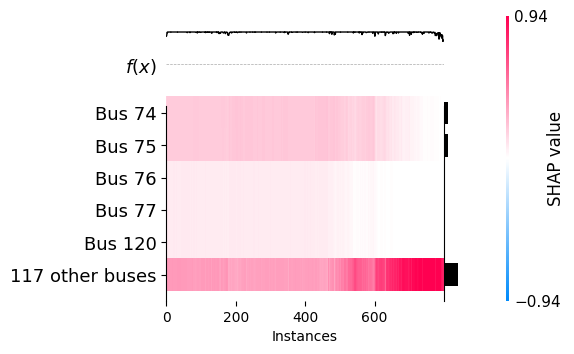

<Axes: xlabel='Instances'>

In [16]:
shap.plots.heatmap(shap_values, max_display=6)

---

In [17]:
explainer = shap.Explainer(model_wrapper, background, feature_names=feature_names)

In [19]:
shap_values = explainer(label_1_samples.squeeze())

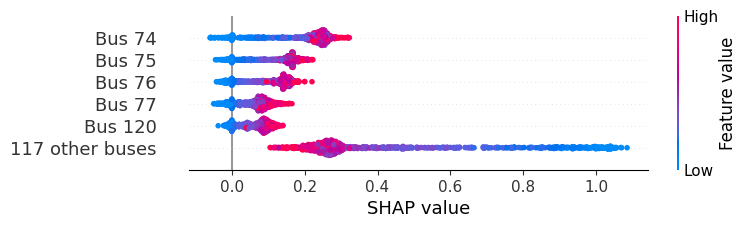

In [20]:
shap.plots.beeswarm(shap_values, max_display=6, plot_size=(7.4, 2))

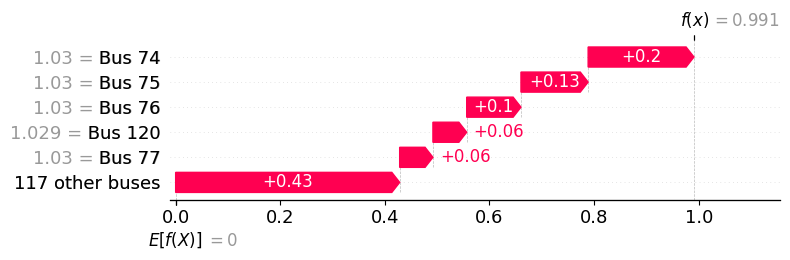

In [21]:
shap.plots.waterfall(shap_values.mean(0), show=False)
plt.tight_layout()
plt.show()

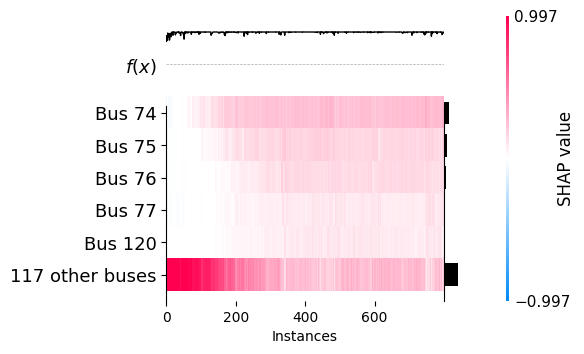

<Axes: xlabel='Instances'>

In [22]:
shap.plots.heatmap(shap_values, max_display=6)